# CS461 讽刺检测项目

这个笔记本用于所有实验：数据探索、模型训练、评估

**流程**：
1. 数据探索
2. 训练基线模型（逻辑回归 + TF-IDF）
3. 尝试进阶模型（SVM、LSTM等）
4. 保存最佳模型
5. 记录所有结果（用于报告）


## 第一步：加载库和数据


In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# 加载数据
train_df = pd.read_csv('train.csv')
valid_df = pd.read_csv('valid.csv')
test_df = pd.read_csv('test.csv')

print(f"训练集: {len(train_df)} 条")
print(f"验证集: {len(valid_df)} 条")
print(f"测试集: {len(test_df)} 条")

# 查看前几行
train_df.head()


训练集: 21464 条
验证集: 716 条
测试集: 966 条


,text,label
0,states slow to shut down weak teacher educatio...,0
1,drone places fresh kill on steps of white house,1
2,report: majority of instances of people gettin...,1
3,"sole remaining lung filled with rich, satisfyi...",1
4,the gop's stockholm syndrome,0


标签分布:
label
0    11248
1    10216
Name: count, dtype: int64

讽刺比例: 47.60%


/Users/three/.local/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/three/.local/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/three/.local/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/three/.local/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/three/.local/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 38598 (\N{CJK UNIFIED IDEOGRAPH-96C6}) m

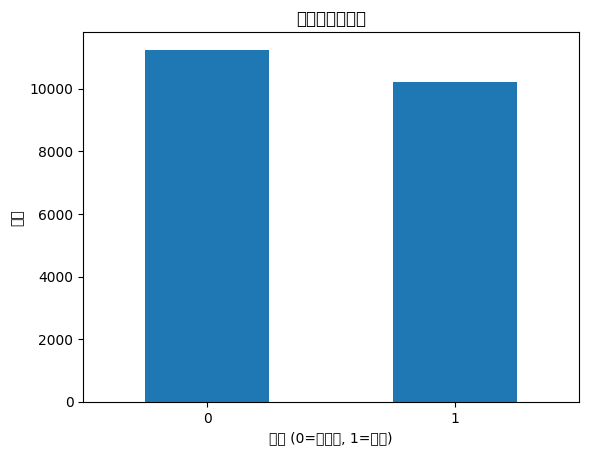


平均文本长度: 62.3 字符

讽刺样例:
  - drone places fresh kill on steps of white house
  - report: majority of instances of people getting lives back on track occur immediately after visit to buffalo wild wings
  - sole remaining lung filled with rich, satisfying flavor

非讽刺样例:
  - states slow to shut down weak teacher education programs
  - the gop's stockholm syndrome
  - trump's game plan


In [2]:
# 标签分布
print("标签分布:")
print(train_df['label'].value_counts())
print(f"\n讽刺比例: {train_df['label'].mean()*100:.2f}%")

# 可视化
train_df['label'].value_counts().plot(kind='bar')
plt.title('训练集标签分布')
plt.xlabel('标签 (0=非讽刺, 1=讽刺)')
plt.ylabel('数量')
plt.xticks(rotation=0)
plt.show()

# 文本长度
train_df['length'] = train_df['text'].str.len()
print(f"\n平均文本长度: {train_df['length'].mean():.1f} 字符")

# 查看样例
print("\n讽刺样例:")
for text in train_df[train_df['label']==1]['text'].head(3):
    print(f"  - {text}")
    
print("\n非讽刺样例:")
for text in train_df[train_df['label']==0]['text'].head(3):
    print(f"  - {text}")


## 第三步：训练基线模型 - 逻辑回归 + TF-IDF

目标：F1 > 0.70


In [3]:
# 简单预处理：转小写
train_texts = train_df['text'].str.lower()
valid_texts = valid_df['text'].str.lower()
test_texts = test_df['text'].str.lower()

# TF-IDF特征提取
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train = vectorizer.fit_transform(train_texts)
X_valid = vectorizer.transform(valid_texts)
X_test = vectorizer.transform(test_texts)

print(f"特征维度: {X_train.shape[1]}")

# 训练逻辑回归
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, train_df['label'])

# 验证集评估
y_pred_valid = model.predict(X_valid)
print("\n验证集性能:")
print(classification_report(valid_df['label'], y_pred_valid))
print(f"F1 Score: {f1_score(valid_df['label'], y_pred_valid):.4f}")

# 测试集评估
y_pred_test = model.predict(X_test)
print("\n测试集性能:")
print(classification_report(test_df['label'], y_pred_test))
print(f"Accuracy:  {accuracy_score(test_df['label'], y_pred_test):.4f}")
print(f"F1 Score:  {f1_score(test_df['label'], y_pred_test):.4f}")


特征维度: 5000

验证集性能:
              precision    recall  f1-score   support

           0       0.83      0.83      0.83       360
           1       0.83      0.83      0.83       356

    accuracy                           0.83       716
   macro avg       0.83      0.83      0.83       716
weighted avg       0.83      0.83      0.83       716

F1 Score: 0.8315

测试集性能:
              precision    recall  f1-score   support

           0       0.85      0.84      0.85       526
           1       0.81      0.82      0.82       440

    accuracy                           0.83       966
   macro avg       0.83      0.83      0.83       966
weighted avg       0.83      0.83      0.83       966

Accuracy:  0.8323
F1 Score:  0.8163



混淆矩阵（测试集）:
[[444  82]
 [ 80 360]]

真负例(TN): 444 | 假正例(FP): 82
假负例(FN): 80 | 真正例(TP): 360


/Users/three/.local/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 38750 (\N{CJK UNIFIED IDEOGRAPH-975E}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Users/three/.local/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 35773 (\N{CJK UNIFIED IDEOGRAPH-8BBD}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Users/three/.local/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 21050 (\N{CJK UNIFIED IDEOGRAPH-523A}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Users/three/.local/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/three/.local/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/three/.local/lib/

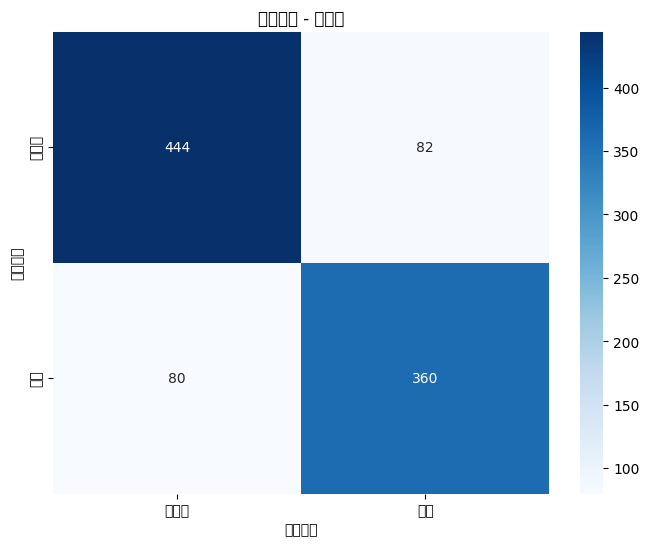


✅ 手动验证计算:
Accuracy: 0.8323
Precision (讽刺类): 0.8145
Recall (讽刺类): 0.8182
F1 (讽刺类): 0.8163


In [4]:
# 验证：查看混淆矩阵
from sklearn.metrics import confusion_matrix

# 测试集混淆矩阵
cm = confusion_matrix(test_df['label'], y_pred_test)
print("\n混淆矩阵（测试集）:")
print(cm)
print(f"\n真负例(TN): {cm[0,0]} | 假正例(FP): {cm[0,1]}")
print(f"假负例(FN): {cm[1,0]} | 真正例(TP): {cm[1,1]}")

# 可视化
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['非讽刺', '讽刺'],
            yticklabels=['非讽刺', '讽刺'])
plt.title('混淆矩阵 - 测试集')
plt.ylabel('真实标签')
plt.xlabel('预测标签')
plt.show()

# 计算详细指标
print("\n✅ 手动验证计算:")
tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision_class1 = tp / (tp + fp)
recall_class1 = tp / (tp + fn)
f1_class1 = 2 * (precision_class1 * recall_class1) / (precision_class1 + recall_class1)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (讽刺类): {precision_class1:.4f}")
print(f"Recall (讽刺类): {recall_class1:.4f}")
print(f"F1 (讽刺类): {f1_class1:.4f}")


## 第四步：保存模型

保存最佳模型用于最终提交


In [ ]:
import joblib

# 保存模型和向量化器
joblib.dump(model, 'models/model_weights.pkl')
joblib.dump(vectorizer, 'models/vectorizer.pkl')

print("✅ 模型已保存到 models/ 文件夹")


---

## 🔄 下一步改进方向

在下面添加新的代码单元格尝试：

1. **更多模型**：
   - SVM
   - Random Forest
   - Naive Bayes
   
2. **更好的特征**：
   - Word2Vec / GloVe
   - 不同的n-gram组合
   - 手工特征（标点、大写等）

3. **深度学习**：
   - LSTM
   - BiLSTM
   - CNN

4. **集成方法**：
   - 投票集成
   - Stacking

记得记录所有实验结果用于报告！
